# Credit Card Fraud Analysis

### Data Understanding & Exploratory Data Analysis (EDA)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
data = pd.read_csv("C:\\Users\\User\\OneDrive\\Documents\\GitHub\\Credit-Card-Fraud-Detection\\data\\creditcard.csv")

In [ ]:
# Seperate the valid and fradulent transactions and show the results
valid_transactions = np.sum(data['Class'] == 0)
fraud_transactions = np.sum(data["Class"] == 1)

print(f"Valid transactions: {valid_transactions}")
print(f"Fraud transactions: {fraud_transactions}")

print(f"Percent of Fraudulent Transactions is {((fraud_transactions / (fraud_transactions +valid_transactions)) * 100).round(2)}%")

Valid transactions: 284315
Fraud transactions: 492
Percent of Fraudulent Transactions is 0.17%


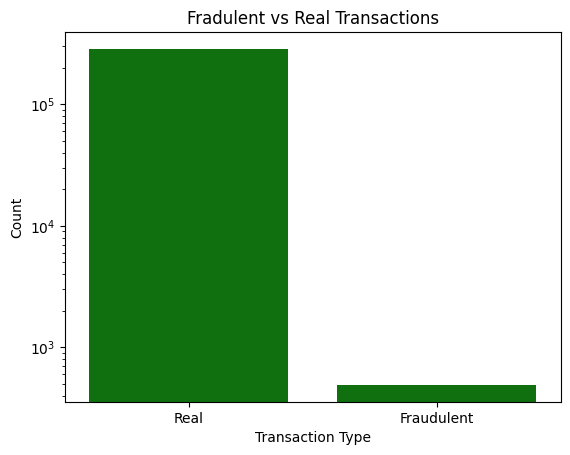

In [ ]:
# Plot for Visualization
sns.countplot(data, x = "Class", color = "green")
plt.yscale("log")
plt.title("Fradulent vs Real Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks([0, 1], ['Real', 'Fraudulent'])
plt.show()

In [29]:
# Calculate Descriptive Statistics for Valid
valid = data[data['Class'] == 0]
fraud = data[data['Class'] == 1]

print(valid["Amount"].describe())

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


In [30]:
print(fraud["Amount"].describe())

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


We can see some pretty interesting things from looking at this descriptive statistics across the two groups. For starters, just by looking at the mean spending of the two groups we can see how fradulent transcations spend more money on average ($122) comapred to the real ones ($88). That being said, the most important obeservation comes from the median, which shows that the median for the fraud transactions is much lower than the real one ($9 compared to the $22 of the real transactions). Looking at the 25% percentile for the fradulent transactions, it lands exactly on $1. This helps tell this story that maybe a lot of fradulent transactins try a $1 ping at the start, and once they realize it works, they start shooting for really big purchases (bringing their mean higher) before the card gets cancelled.

#### Let's run a correlation heat map to try and make the V columns understandable (tells us which features have more of an impact)

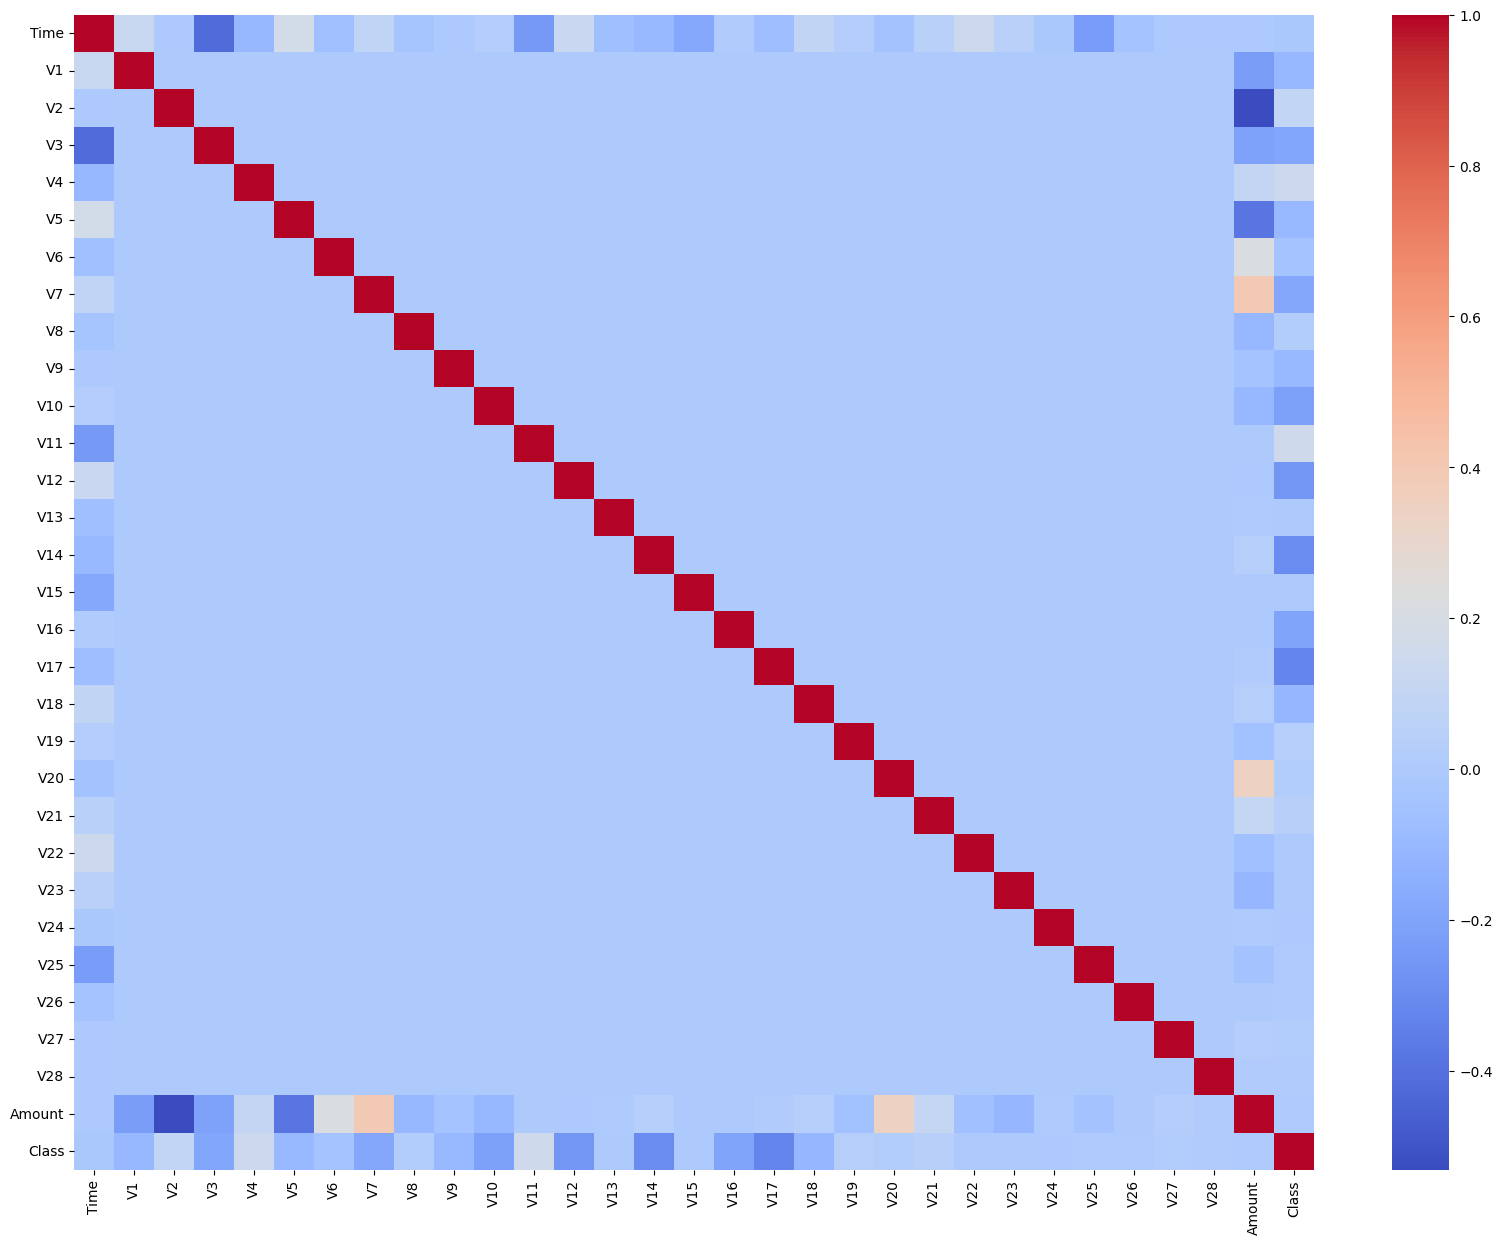

In [33]:
# Correlation Matrix
correlation_matrix = data.corr()

# Plot it
plt.figure(figsize=(20,15))
sns.heatmap(correlation_matrix, cmap="coolwarm")
plt.show()

### Negative Correlators (ranked most to least)
V17, V14, V12, V10

### Positive Correlators
V11, V4, V2

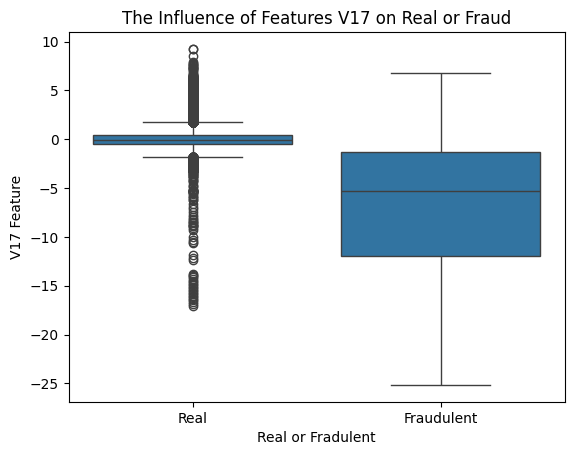

In [34]:
sns.boxplot(data, x = "Class", y = "V17")
plt.title("The Influence of Features V17 on Real or Fraud")
plt.xlabel("Real or Fradulent")
plt.xticks([0, 1], ['Real', 'Fraudulent'])
plt.ylabel("V17 Feature")
plt.show()